In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

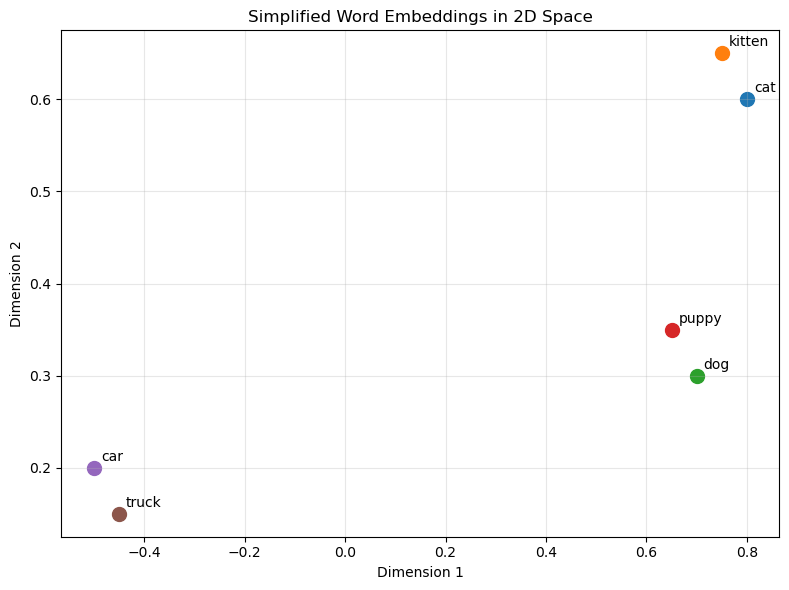

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [6]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [7]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

## Create Embedding

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embeddings

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [12]:
## Create first embedding
text = "Hello, I am learning about embeddings!"
embedded_text = embeddings.embed_query(text)
print(f"Text is: {text}")
print(f"Length of embedded vector: {len(embedded_text)}")
print(f"Embedded text is: {embedded_text}")
type(embedded_text)

Text is: Hello, I am learning about embeddings!
Length of embedded vector: 384
Embedded text is: [-0.018163273110985756, -0.09955165535211563, 0.013816061429679394, -0.008125964552164078, 0.014152269810438156, 0.0640648901462555, -0.006253400817513466, -0.0030179086606949568, 0.025287244468927383, -0.02019864320755005, 0.024329690262675285, 0.07435064017772675, 0.051177214831113815, 0.022038502618670464, -0.05830622464418411, 0.015268249437212944, 0.023584336042404175, 0.09455393254756927, -0.0650884211063385, 0.01329666469246149, -0.020497549325227737, -0.05690852552652359, 0.03030332736670971, -0.08365613222122192, 0.02659633755683899, -0.01523147989064455, -0.043615397065877914, 0.05398400127887726, 0.0902571752667427, -0.08893882483243942, 0.03964461758732796, -0.008835060521960258, -0.03034372255206108, 0.07425563782453537, -0.05409921333193779, 0.11107999086380005, 0.0368998721241951, -0.008959826081991196, -0.06140242889523506, -0.0031433221884071827, 0.02195817604660988, 0.0422

list

In [ ]:
sentences = [
    "I love machine learning.",
    "The cat is on the roof.",
    "Artificial intelligence is fascinating.",
    "The dog is barking loudly.",
    "I enjoy sunny days."]

sentence_embeddings = embeddings.embed_documents(sentences)
print(f"Number of sentences: {len(sentences)}")

for sentence, embedding in zip(sentences, sentence_embeddings):
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding[:5]}...")  # Print first 5 dimensions for brevity
    print(f"Embedding length: {len(embedding)}\n")



Number of sentences: 5
Sentence: I love machine learning.
Embedding: [-0.01685112528502941, -0.0707218125462532, 0.08554109930992126, -0.0017661279998719692, 0.04520877078175545]...
Embedding length: 384

Sentence: The cat is on the roof.
Embedding: [0.09014216810464859, 0.07564274966716766, 0.02024746686220169, 0.01272277906537056, -0.04801316186785698]...
Embedding length: 384

Sentence: Artificial intelligence is fascinating.
Embedding: [-0.004465955775231123, -0.06313368678092957, 0.06713645905256271, 6.866257899673656e-05, -0.011738603934645653]...
Embedding length: 384

Sentence: The dog is barking loudly.
Embedding: [0.06118752062320709, -0.05239829048514366, 0.027781225740909576, 0.0747847855091095, -0.04703235998749733]...
Embedding length: 384

Sentence: I enjoy sunny days.
Embedding: [-0.038759496062994, -0.002989680739119649, 0.07764896005392075, 0.08858438581228256, 0.02756158635020256]...
Embedding length: 384

Embedding for 'I love machine learning.': [0.0010150031885132

# Open AI Embedding

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [24]:
from langchain_openai import OpenAIEmbeddings
openai_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

text = "Hello, I am learning about embeddings!"
embedded_text = openai_embeddings.embed_query(text)
print(f"Text is: {text}")
print(f"Length of embedded vector: {len(embedded_text)}")
print(f"Embedded text is: {embedded_text}")


Text is: Hello, I am learning about embeddings!
Length of embedded vector: 1536
Embedded text is: [0.003326416015625, -0.044525146484375, 0.009368896484375, 0.0083465576171875, -0.036651611328125, -0.0179290771484375, 0.026092529296875, 0.036163330078125, -0.015655517578125, 0.008544921875, 0.00811767578125, -0.043731689453125, -0.010498046875, -0.06768798828125, -0.007144927978515625, 0.0274810791015625, -0.023162841796875, 0.0323486328125, 0.00505828857421875, 0.04901123046875, 0.037933349609375, -0.0328369140625, 0.00316619873046875, 0.054290771484375, -0.00492095947265625, -0.0216064453125, 0.040435791015625, 0.04833984375, -0.0025787353515625, -0.00688934326171875, 0.005702972412109375, -0.026611328125, -0.00321197509765625, -0.041351318359375, -0.01534271240234375, 0.033660888671875, -0.051544189453125, 0.038360595703125, -0.031402587890625, 0.021331787109375, 0.012908935546875, -0.01049041748046875, -0.03680419921875, 0.0269622802734375, -0.047607421875, 0.039886474609375, -0.05

In [25]:
sentence_embeddings = openai_embeddings.embed_documents(sentences)
print(f"Number of sentences: {len(sentences)}")
for sentence, embedding in zip(sentences, sentence_embeddings):
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding[:5]}...")  # Print first 5 dimensions for brevity
    print(f"Embedding length: {len(embedding)}\n")

Number of sentences: 5
Sentence: I love machine learning.
Embedding: [-0.016082763671875, -0.0184173583984375, -0.02777099609375, -0.035003662109375, 0.034698486328125]...
Embedding length: 1536

Sentence: The cat is on the roof.
Embedding: [-0.00804901123046875, -0.01739501953125, 0.034576416015625, 0.05291748046875, 0.0009021759033203125]...
Embedding length: 1536

Sentence: Artificial intelligence is fascinating.
Embedding: [-0.01444244384765625, -0.020751953125, -0.03802490234375, 0.0143280029296875, 0.0235748291015625]...
Embedding length: 1536

Sentence: The dog is barking loudly.
Embedding: [0.029510498046875, 0.0260772705078125, 0.0286712646484375, 0.0262451171875, -0.05303955078125]...
Embedding length: 1536

Sentence: I enjoy sunny days.
Embedding: [0.0246124267578125, -0.038482666015625, -0.002323150634765625, 0.01100921630859375, 0.06048583984375]...
Embedding length: 1536



# Cosine similarity example with OpenAI embeddings

In [26]:
sentences

['I love machine learning.',
 'The cat is on the roof.',
 'Artificial intelligence is fascinating.',
 'The dog is barking loudly.',
 'I enjoy sunny days.']

In [27]:
openai_embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001CA01F09BD0>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001CA01F0A490>, model='text-embedding-3-small', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [28]:
sentence_embeddings

[[-0.016082763671875,
  -0.0184173583984375,
  -0.02777099609375,
  -0.035003662109375,
  0.034698486328125,
  -0.0026092529296875,
  -0.00033402442932128906,
  0.03851318359375,
  -0.069091796875,
  0.0112457275390625,
  0.0036468505859375,
  -0.03448486328125,
  -0.048919677734375,
  -0.0165863037109375,
  0.034820556640625,
  0.01041412353515625,
  -0.01409149169921875,
  -0.006259918212890625,
  0.048370361328125,
  0.0090179443359375,
  -0.01092529296875,
  0.01381683349609375,
  0.0031108856201171875,
  -0.0372314453125,
  0.01233673095703125,
  -0.04327392578125,
  0.04144287109375,
  0.034271240234375,
  0.032318115234375,
  -0.024078369140625,
  0.01544952392578125,
  -0.0137786865234375,
  -0.0618896484375,
  -0.035675048828125,
  0.01433563232421875,
  -0.01367950439453125,
  -0.037384033203125,
  -0.00027823448181152344,
  -0.037811279296875,
  0.0251617431640625,
  -0.0128936767578125,
  -0.05804443359375,
  0.05059814453125,
  0.050079345703125,
  -0.04034423828125,
  -0.

In [29]:
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        sim = cosine_similarity(sentence_embeddings[i], sentence_embeddings[j])
        print(f"Similarity between '{sentences[i]}' and '{sentences[j]}': {sim:.4f}")

Similarity between 'I love machine learning.' and 'The cat is on the roof.': 0.0481
Similarity between 'I love machine learning.' and 'Artificial intelligence is fascinating.': 0.5496
Similarity between 'I love machine learning.' and 'The dog is barking loudly.': 0.1226
Similarity between 'I love machine learning.' and 'I enjoy sunny days.': 0.2089
Similarity between 'The cat is on the roof.' and 'Artificial intelligence is fascinating.': 0.0846
Similarity between 'The cat is on the roof.' and 'The dog is barking loudly.': 0.2418
Similarity between 'The cat is on the roof.' and 'I enjoy sunny days.': 0.1556
Similarity between 'Artificial intelligence is fascinating.' and 'The dog is barking loudly.': 0.0606
Similarity between 'Artificial intelligence is fascinating.' and 'I enjoy sunny days.': 0.1713
Similarity between 'The dog is barking loudly.' and 'I enjoy sunny days.': 0.1011


# Semantic search

In [30]:
documents = [
    "Langchain is a powerful framework for building applications with language models.",
    "OpenAI provides various models for natural language processing tasks.",
    "Python is a versatile programming language widely used in AI and data science."
    "Embeddings convert text into numerical vectors that capture semantic meaning."
    "The weather is sunny today."
]

In [32]:
query = "What is Langchain?"


In [37]:
def semantic_search(query, documents, embeddings, top_k=3):
    query_embedding = embeddings.embed_query(query)
    document_embeddings = embeddings.embed_documents(documents)

    similarities = []
    # Calculate cosine similarity between query and each document
    for i, doc_embedding in enumerate(document_embeddings):
        sim = cosine_similarity(query_embedding, doc_embedding)
        similarities.append((sim, documents[i]))

    # Sort documents by similarity and return top_k results 
    similarities.sort(reverse=True)
    return similarities[:top_k]


In [38]:
results = semantic_search(query, documents, openai_embeddings)
print(f"Query: {query}\n")
print("Top relevant documents:")
for sim, doc in results:
    print(f"Similarity: {sim:.4f} - Document: {doc}")

Query: What is Langchain?

Top relevant documents:
Similarity: 0.5824 - Document: Langchain is a powerful framework for building applications with language models.
Similarity: 0.1593 - Document: OpenAI provides various models for natural language processing tasks.
Similarity: 0.0243 - Document: Python is a versatile programming language widely used in AI and data science.Embeddings convert text into numerical vectors that capture semantic meaning.The weather is sunny today.
